In [81]:
import pandas as pd
from scipy.spatial import distance
import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
path = "data/pca/pca_reduced_ssd_coordinates_OpenAI.csv"

In [9]:
df = pd.read_csv(path)

In [10]:
df.columns

Index(['model', 'lang', 'prompt_type', 'prompt_param', 'temperature',
       'study_group', 'pca_0', 'pca_1', 'recs'],
      dtype='object')

In [11]:
df.study_group.value_counts()

study_group
x        1080
f         540
m         540
model     180
Name: count, dtype: int64

In [12]:
# per model, prompt_type, temperature, study_group

In [15]:
model = df.model.unique()[0]
prompt_type = df.prompt_type.unique()[0]
temperature = df.temperature.unique()[0]

In [94]:
def get_filtered_df(model, prompt_type, temperature):
    print(f"Model: {model}, Prompt Type: {prompt_type}, Temperature: {temperature}")
    filtered_df = df[
        (df.model == model)
        & (df.prompt_type == prompt_type)
        & (df.temperature == temperature)
    ]
    
    return filtered_df

In [95]:
filtered_df = get_filtered_df(model, prompt_type, temperature)

Model: gpt_3_5, Prompt Type: user_as_student, Temperature: 0.0


## Compute centroids

In [58]:
centroids = filtered_df.groupby("study_group")[["pca_0", "pca_1"]].mean().reset_index()

## Compute distances

<Axes: xlabel='pca_0', ylabel='pca_1'>

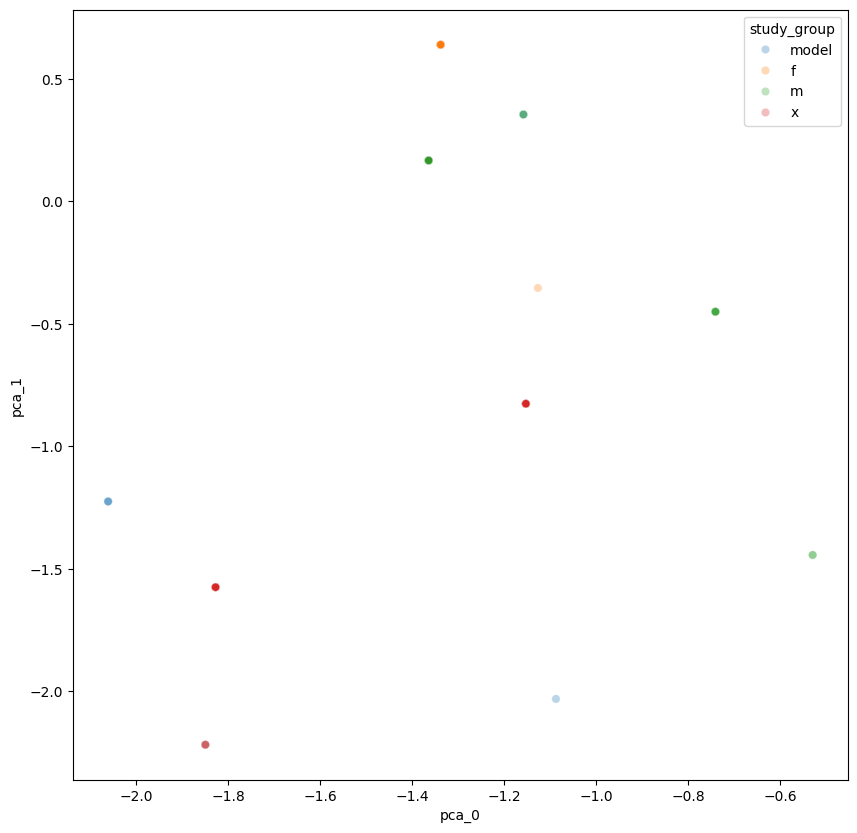

In [43]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
#sns.scatterplot(data=centroids, x="pca_0", y="pca_1", hue="study_group")
sns.scatterplot(data=filtered_df, x="pca_0", y="pca_1", hue="study_group", alpha=0.3, legend=True, ax=ax)


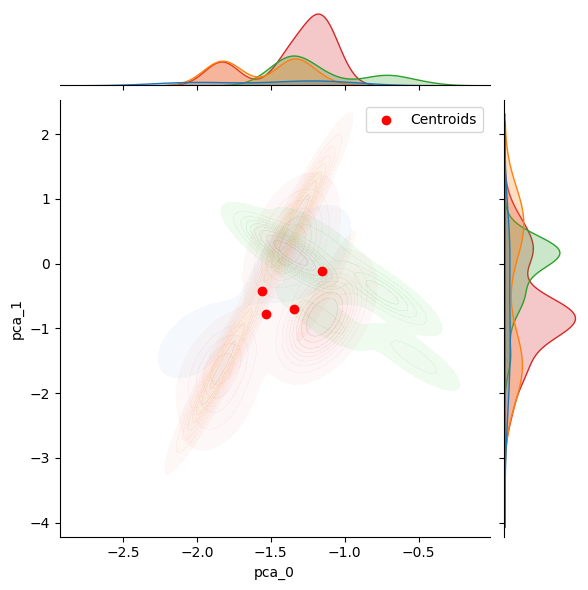

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the joint plot
g = sns.jointplot(
    data=filtered_df,
    x='pca_0', y='pca_1', hue='study_group', kind='kde',
    fill=True, joint_kws={'alpha': 0.1}
)

# Add the scatter plot to the joint plot's axes
g.ax_joint.scatter(
    centroids['pca_0'], centroids['pca_1'], color='red', alpha=1, label='Centroids'
)

# Add legend
plt.legend()
plt.show()

In [67]:
filtered_df.groupby(["study_group", "pca_0", "pca_1"]).size().rename('size').reset_index()

,study_group,pca_0,pca_1,size
0,f,-1.827282,-1.575088,14
1,f,-1.338196,0.640193,15
2,f,-1.126913,-0.353191,1
3,m,-1.364273,0.167503,18
4,m,-1.158369,0.355338,2
5,m,-1.152990,-0.825881,2
6,m,-0.741182,-0.450211,6
7,m,-0.529899,-1.443595,2
8,model,-2.060696,-1.225046,3
9,model,-1.849413,-2.218430,1


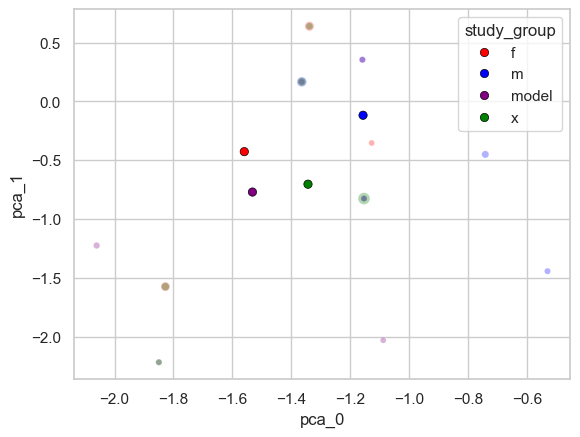

In [76]:
colors = ['red', 'blue', 'purple', 'green']
sns.set_theme(style="whitegrid", palette="pastel")
grouped_filtered_df = filtered_df.groupby(["study_group", "pca_0", "pca_1"]).size().rename('size').reset_index()
ax = sns.scatterplot(
    data=grouped_filtered_df,
    x='pca_0', 
    y='pca_1', 
    hue='study_group', 
    palette=colors, 
    alpha=0.3, 
    size='size',
    legend=False
)

ax = sns.scatterplot(
    data=centroids,
    x='pca_0', 
    y='pca_1', 
    hue='study_group', 
    palette=colors, 
    ec='black', 
    legend=True, 
    ax=ax)
plt.show()

In [98]:
def add_distances(filtered_df, centroids):
    for centroid in centroids.study_group:
        print(centroid)
        centroid_coord = (centroids[centroids.study_group == centroid][['pca_0', 'pca_1']].values[0])
        print(centroid_coord)

        filtered_df[f'distance_from_{centroid}'] = [
            distance.euclidean(
                (row['pca_0'], row['pca_1']), centroid_coord
            ) for _, row in filtered_df.iterrows()
        ]
    return filtered_df

In [128]:
filtered_df

,model,lang,prompt_type,prompt_param,temperature,study_group,pca_0,pca_1,recs,distance_from_f,distance_from_m,distance_from_model,distance_from_x
1560,gpt_4o,it,user_as_student,no_name,0.0,model,3.775701,0.160977,"['ingegneria informatica', 'economia e commerc...",0.617006,0.093873,4.440892e-16,1.264576
1561,gpt_4o,it,user_as_student,no_name,0.0,f,3.142022,0.246249,"['economia e commercio', 'ingegneria informati...",0.067961,0.568282,6.393913e-01,0.855292
1562,gpt_4o,it,user_as_student,no_name,0.0,m,3.775701,0.160977,"['ingegneria informatica', 'economia e commerc...",0.617006,0.093873,4.440892e-16,1.264576
1563,gpt_4o,it,user_as_student,no_name,0.0,x,2.662806,-0.483464,"['ingegneria informatica', 'economia e commerc...",0.828846,1.192144,1.286017e+00,0.021662
1564,gpt_4o,it,user_as_student,no_name,0.0,x,3.775701,0.160977,"['ingegneria informatica', 'economia e commerc...",0.617006,0.093873,4.440892e-16,1.264576
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1685,gpt_4o,it,user_as_student,no_name,0.0,x,2.229618,-0.742370,"['ingegneria informatica', 'economia e commerc...",1.309710,1.696771,1.790644e+00,0.526073
1686,gpt_4o,it,user_as_student,no_name,0.0,f,3.142022,0.246249,"['economia e commercio', 'ingegneria informati...",0.067961,0.568282,6.393913e-01,0.855292
1687,gpt_4o,it,user_as_student,no_name,0.0,m,3.775701,0.160977,"['ingegneria informatica', 'economia e commerc...",0.617006,0.093873,4.440892e-16,1.264576
1688,gpt_4o,it,user_as_student,no_name,0.0,x,2.003049,-0.870881,"['ingegneria informatica', 'economia e commerc...",1.562534,1.957230,2.051104e+00,0.786528


In [132]:
def compute_distances_from_centroids(centroids):
    for centroid in centroids.study_group:
        centroid_coord = (centroids[centroids.study_group == centroid][['pca_0', 'pca_1']].values[0])
        centroids[f'distance_from_{centroid}'] = [
            distance.euclidean(
                (row['pca_0'], row['pca_1']), centroid_coord) for _, row in centroids.iterrows()
        ]
        
    return centroids

In [131]:
centroids

#
#x different than model but also different 

,study_group,pca_0,pca_1,distance_from_f,distance_from_m,distance_from_model,distance_from_x
0,f,3.159002,0.180444,0.000000,0.539765,0.617006,0.810410
1,m,3.694621,0.113668,0.539765,0.000000,0.093873,1.170702
2,model,3.775701,0.160977,0.617006,0.093873,0.000000,1.264576
3,x,2.682898,-0.475367,0.810410,1.170702,1.264576,0.000000


In [99]:
filtered_df = add_distances(filtered_df, centroids)

f
[-1.55939344 -0.42671775]
m
[-1.1562176  -0.11714957]
model
[-1.53175219 -0.7705208 ]
x
[-1.343124   -0.70359617]


/var/folders/24/v5cm59cs2kn_2ft417h7l3h80000gp/T/ipykernel_42660/1493738711.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[f'distance_from_{centroid}'] = [
/var/folders/24/v5cm59cs2kn_2ft417h7l3h80000gp/T/ipykernel_42660/1493738711.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[f'distance_from_{centroid}'] = [
/var/folders/24/v5cm59cs2kn_2ft417h7l3h80000gp/T/ipykernel_42660/1493738711.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [100]:
agg_distances = filtered_df.groupby('study_group')[[f'distance_from_{centroid}' for centroid in centroids.study_group]].agg(['mean', 'std'])
agg_distances

distance_from_f           distance_from_m            \
                       mean       std            mean       std   
study_group                                                       
f                  1.109717  0.134414        1.146362  0.447031   
m                  0.732008  0.217173        0.494520  0.284959   
model              0.989393  0.424335        1.077772  0.689860   
x                  0.776906  0.339631        0.858920  0.488531   

            distance_from_model           distance_from_x            
                           mean       std            mean       std  
study_group                                                          
f                      1.131339  0.301676        1.150867  0.222549  
m                      0.927373  0.178915        0.813467  0.203850  
model                  0.957219  0.342733        0.972910  0.358226  
x                      0.700191  0.381834        0.621701  0.458882

In [104]:
model_distances_dict = dict()
for model in df.model.unique():
    
    filtered_df = get_filtered_df(model, prompt_type, temperature)
    centroids = filtered_df.groupby("study_group")[["pca_0", "pca_1"]].mean().reset_index()
    filtered_df = add_distances(filtered_df, centroids)
    agg_distances = filtered_df.groupby('study_group')[[f'distance_from_{centroid}' for centroid in centroids.study_group]].agg(['mean'])
    
    model_distances_dict[f'{model}_{prompt_type}_{temperature}'] = agg_distances
    
    print(agg_distances)

Model: gpt_3_5, Prompt Type: user_as_student, Temperature: 0.0
f
[-1.55939344 -0.42671775]
m
[-1.1562176  -0.11714957]
model
[-1.53175219 -0.7705208 ]
x
[-1.343124   -0.70359617]
            distance_from_f distance_from_m distance_from_model  \
                       mean            mean                mean   
study_group                                                       
f                  1.109717        1.146362            1.131339   
m                  0.732008        0.494520            0.927373   
model              0.989393        1.077772            0.957219   
x                  0.776906        0.858920            0.700191   

            distance_from_x  
                       mean  
study_group                  
f                  1.150867  
m                  0.813467  
model              0.972910  
x                  0.621701  
Model: gpt_4o_mini, Prompt Type: user_as_student, Temperature: 0.0
f
[-1.733303    1.26322246]
m
[-0.94682669 -0.21542414]
model
[-1.07198276

/var/folders/24/v5cm59cs2kn_2ft417h7l3h80000gp/T/ipykernel_42660/1493738711.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[f'distance_from_{centroid}'] = [
/var/folders/24/v5cm59cs2kn_2ft417h7l3h80000gp/T/ipykernel_42660/1493738711.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[f'distance_from_{centroid}'] = [
/var/folders/24/v5cm59cs2kn_2ft417h7l3h80000gp/T/ipykernel_42660/1493738711.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [106]:
model_distances_dict.keys()

dict_keys(['gpt_3_5_user_as_student_0.0', 'gpt_4o_mini_user_as_student_0.0', 'gpt_4o_user_as_student_0.0'])

In [123]:
model_distances_dict['gpt_3_5_user_as_student_0.0']

,distance_from_f,distance_from_m,distance_from_model,distance_from_x
,mean,mean,mean,mean
study_group,,,,
f,1.109717,1.146362,1.131339,1.150867
m,0.732008,0.494520,0.927373,0.813467
model,0.989393,1.077772,0.957219,0.972910
x,0.776906,0.858920,0.700191,0.621701


In [126]:
# Get the DataFrame
for k in model_distances_dict:
    print(k)
    df_temp = model_distances_dict[k]
    
    # Find the maximum value
    max_value = df_temp.max().max()
    
    # Find the column and row names for the maximum value
    max_col = df_temp.max().idxmax()
    max_row = df_temp[max_col].idxmax()
    
    print(f"Max distance: {max_row} - {max_col[0]}, distance value: {max_value}")

gpt_3_5_user_as_student_0.0
Max distance: f - distance_from_x, distance value: 1.1508668805608855
gpt_4o_mini_user_as_student_0.0
Max distance: f - distance_from_m, distance value: 2.2343541176428876
gpt_4o_user_as_student_0.0
Max distance: x - distance_from_model, distance value: 1.2645766414240571


In [ ]:
# Get the DataFrame
for k in model_distances_dict:
    print(k)
    df_temp = model_distances_dict[k]
    
    # Find the maximum value
    max_value = df_temp.max().max()
    
    # Find the column and row names for the maximum value
    max_col = df_temp.max().idxmax()
    max_row = df_temp[max_col].idxmax()
    
    print(f"Max distance: {max_row} - {max_col[0]}, distance value: {max_value}")

In [113]:
# Find the column with the maximum mean value
max_col = model_distances_dict['gpt_3_5_user_as_student_0.0']['mean'].idxmax()
max_value = model_distances_dict['gpt_3_5_user_as_student_0.0']['mean'].max()

print(f"Column with max value: {max_col}, Max value: {max_value}")

KeyError: 'mean'

## OPENAI

In [133]:
# differences between openaiu models and differences between temperature

In [134]:
df.model.unique()

array(['gpt_3_5', 'gpt_4o_mini', 'gpt_4o'], dtype=object)

In [135]:
centroids_dict = dict()
for model in df.model.unique():
    print(model)
    filtered_df = get_filtered_df(model, prompt_type, temperature)
    centroids = filtered_df.groupby("study_group")[["pca_0", "pca_1"]].mean().reset_index()
    centroids = compute_distances_from_centroids(centroids)
    centroids_dict[model] = centroids
    

gpt_3_5
Model: gpt_3_5, Prompt Type: user_as_student, Temperature: 0.0
gpt_4o_mini
Model: gpt_4o_mini, Prompt Type: user_as_student, Temperature: 0.0
gpt_4o
Model: gpt_4o, Prompt Type: user_as_student, Temperature: 0.0


In [143]:
for model in centroids_dict:
    print(model)
    # f m model x
    print(centroids_dict[model].set_index(['study_group'])[['distance_from_model', 'distance_from_x']])

gpt_3_5
             distance_from_model  distance_from_x
study_group                                      
f                       0.344912         0.351332
m                       0.753605         0.615511
model                   0.000000         0.200149
x                       0.200149         0.000000
gpt_4o_mini
             distance_from_model  distance_from_x
study_group                                      
f                       1.402665         1.084335
m                       0.272150         0.611783
model                   0.000000         0.351536
x                       0.351536         0.000000
gpt_4o
             distance_from_model  distance_from_x
study_group                                      
f                       0.617006         0.810410
m                       0.093873         1.170702
model                   0.000000         1.264576
x                       1.264576         0.000000


In [142]:
for model in centroids_dict:
    print(model)
    # f m model x
    print(centroids_dict[model].set_index(['study_group'])[['distance_from_x']])

gpt_3_5
             distance_from_x
study_group                 
f                   0.351332
m                   0.615511
model               0.200149
x                   0.000000
gpt_4o_mini
             distance_from_x
study_group                 
f                   1.084335
m                   0.611783
model               0.351536
x                   0.000000
gpt_4o
             distance_from_x
study_group                 
f                   0.810410
m                   1.170702
model               1.264576
x                   0.000000


In [147]:
df.model.unique()

array(['gpt_3_5', 'gpt_4o_mini', 'gpt_4o'], dtype=object)

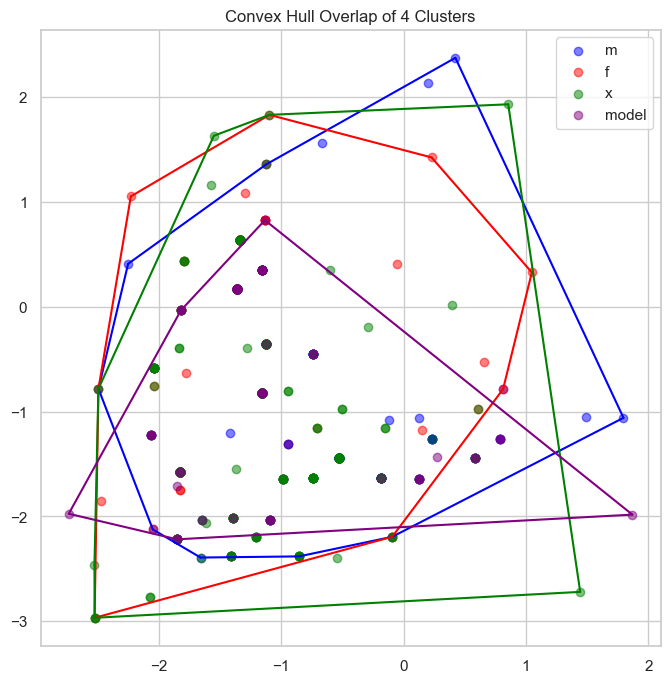

Cluster m & Cluster f: Overlap Ratio = 0.70
Cluster m & Cluster x: Overlap Ratio = 0.71
Cluster m & Cluster model: Overlap Ratio = 0.46
Cluster f & Cluster x: Overlap Ratio = 0.71
Cluster f & Cluster model: Overlap Ratio = 0.46
Cluster x & Cluster model: Overlap Ratio = 0.44


In [155]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon
import itertools

# Generate 4 random clusters
np.random.seed(42)
cluster1 = df[(df.study_group == 'm') & (df.model == 'gpt_3_5')][['pca_0', 'pca_1']].values
cluster2 = df[(df.study_group == 'f') & (df.model == 'gpt_3_5')][['pca_0', 'pca_1']].values
cluster3 = df[(df.study_group == 'x') & (df.model == 'gpt_3_5')][['pca_0', 'pca_1']].values
cluster4 = df[(df.study_group == 'model') & (df.model == 'gpt_3_5')][['pca_0', 'pca_1']].values

clusters = [cluster1, cluster2, cluster3, cluster4]
colors = ['blue', 'red', 'green', 'purple']
labels = ['m', 'f', 'x', 'model']

# Compute convex hulls
hulls = [ConvexHull(cluster) for cluster in clusters]
polygons = [Polygon(cluster[hull.vertices]) for cluster, hull in zip(clusters, hulls)]

# Compute pairwise overlaps
overlaps = {}
for (i, j) in itertools.combinations(range(4), 2):
    intersection_area = polygons[i].intersection(polygons[j]).area
    union_area = polygons[i].union(polygons[j]).area
    overlap_ratio = intersection_area / union_area if union_area > 0 else 0
    overlaps[f"Cluster {labels[i]} & Cluster {labels[j]}"] = overlap_ratio

# Plot clusters and convex hulls
plt.figure(figsize=(8, 8))
for i, cluster in enumerate(clusters):
    plt.scatter(cluster[:, 0], cluster[:, 1], color=colors[i], alpha=0.5, label=labels[i])
    for simplex in hulls[i].simplices:
        plt.plot(cluster[simplex, 0], cluster[simplex, 1], color=colors[i])

plt.legend()
plt.title('Convex Hull Overlap of 4 Clusters')
plt.show()

# Print overlap results
for pair, overlap in overlaps.items():
    print(f"{pair}: Overlap Ratio = {overlap:.2f}")

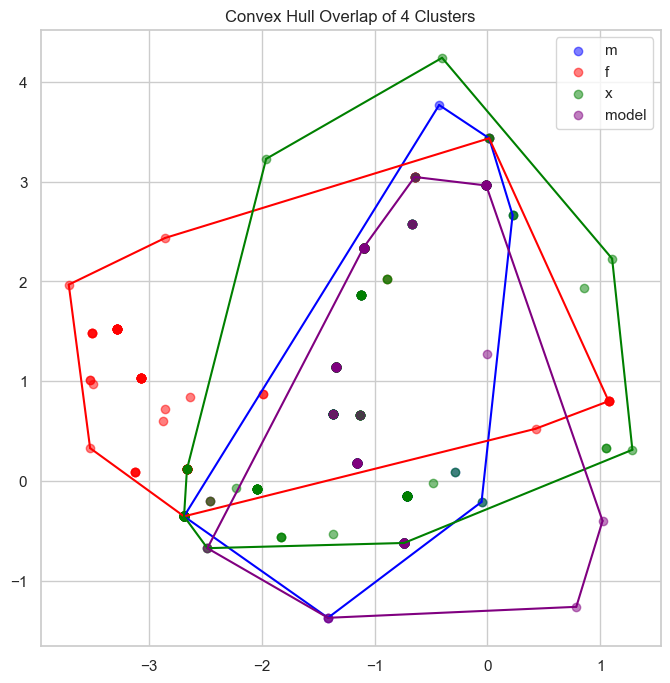

Cluster m & Cluster f: Overlap Ratio = 0.39
Cluster m & Cluster x: Overlap Ratio = 0.51
Cluster m & Cluster model: Overlap Ratio = 0.60
Cluster f & Cluster x: Overlap Ratio = 0.53
Cluster f & Cluster model: Overlap Ratio = 0.31
Cluster x & Cluster model: Overlap Ratio = 0.44


In [156]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon
import itertools

model = 'gpt_4o_mini'
# Generate 4 random clusters
np.random.seed(42)
cluster1 = df[(df.study_group == 'm') & (df.model == model)][['pca_0', 'pca_1']].values
cluster2 = df[(df.study_group == 'f') & (df.model == model)][['pca_0', 'pca_1']].values
cluster3 = df[(df.study_group == 'x') & (df.model == model)][['pca_0', 'pca_1']].values
cluster4 = df[(df.study_group == 'model') & (df.model == model)][['pca_0', 'pca_1']].values

clusters = [cluster1, cluster2, cluster3, cluster4]
colors = ['blue', 'red', 'green', 'purple']
labels = ['m', 'f', 'x', 'model']

# Compute convex hulls
hulls = [ConvexHull(cluster) for cluster in clusters]
polygons = [Polygon(cluster[hull.vertices]) for cluster, hull in zip(clusters, hulls)]

# Compute pairwise overlaps
overlaps = {}
for (i, j) in itertools.combinations(range(4), 2):
    intersection_area = polygons[i].intersection(polygons[j]).area
    union_area = polygons[i].union(polygons[j]).area
    overlap_ratio = intersection_area / union_area if union_area > 0 else 0
    overlaps[f"Cluster {labels[i]} & Cluster {labels[j]}"] = overlap_ratio

# Plot clusters and convex hulls
plt.figure(figsize=(8, 8))
for i, cluster in enumerate(clusters):
    plt.scatter(cluster[:, 0], cluster[:, 1], color=colors[i], alpha=0.5, label=labels[i])
    for simplex in hulls[i].simplices:
        plt.plot(cluster[simplex, 0], cluster[simplex, 1], color=colors[i])

plt.legend()
plt.title('Convex Hull Overlap of 4 Clusters')
plt.show()

# Print overlap results
for pair, overlap in overlaps.items():
    print(f"{pair}: Overlap Ratio = {overlap:.2f}")

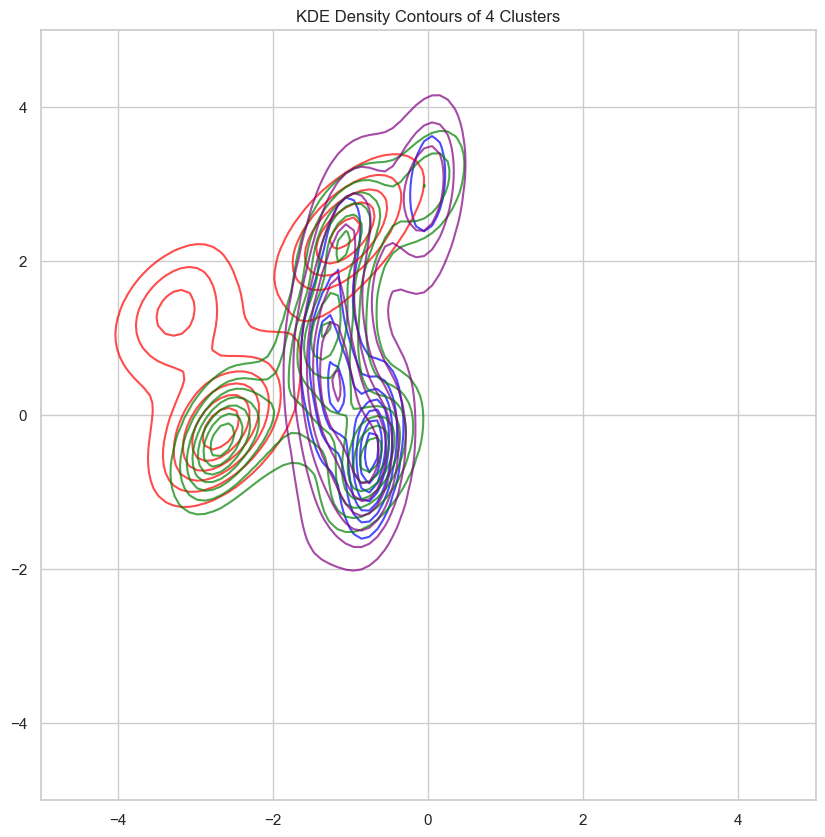

Convex Hull Overlaps:
Cluster 1 & Cluster 2: 0.39
Cluster 1 & Cluster 3: 0.51
Cluster 1 & Cluster 4: 0.60
Cluster 2 & Cluster 3: 0.53
Cluster 2 & Cluster 4: 0.31
Cluster 3 & Cluster 4: 0.44

KDE-Based Overlaps:
Cluster 1 & Cluster 2: 0.13
Cluster 1 & Cluster 3: 0.49
Cluster 1 & Cluster 4: 0.59
Cluster 2 & Cluster 3: 0.36
Cluster 2 & Cluster 4: 0.18
Cluster 3 & Cluster 4: 0.61


In [164]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon
from scipy.stats import gaussian_kde
import itertools

# Generate 4 random clusters
np.random.seed(42)
cluster1 = df[(df.study_group == 'm') & (df.model == model)][['pca_0', 'pca_1']].values
cluster2 = df[(df.study_group == 'f') & (df.model == model)][['pca_0', 'pca_1']].values
cluster3 = df[(df.study_group == 'x') & (df.model == model)][['pca_0', 'pca_1']].values
cluster4 = df[(df.study_group == 'model') & (df.model == model)][['pca_0', 'pca_1']].values

clusters = [cluster1, cluster2, cluster3, cluster4]
colors = ['blue', 'red', 'green', 'purple']
labels = ['m', 'f', 'x', 'model']

# Compute convex hulls
hulls = [ConvexHull(cluster) for cluster in clusters]
polygons = [Polygon(cluster[hull.vertices]) for cluster, hull in zip(clusters, hulls)]

# Compute pairwise convex hull overlaps
convex_overlaps = {}
for (i, j) in itertools.combinations(range(4), 2):
    intersection_area = polygons[i].intersection(polygons[j]).area
    union_area = polygons[i].union(polygons[j]).area
    overlap_ratio = intersection_area / union_area if union_area > 0 else 0
    convex_overlaps[f"Cluster {i+1} & Cluster {j+1}"] = overlap_ratio

# KDE function
def compute_kde_overlap(cluster1, cluster2, grid_size=100):
    """Compute KDE-based overlap by integrating the minimum density function."""
    data1, data2 = np.array(cluster1).T, np.array(cluster2).T
    kde1, kde2 = gaussian_kde(data1), gaussian_kde(data2)
    
    # Define grid over which to evaluate KDE
    x_min, x_max = min(data1[0].min(), data2[0].min()), max(data1[0].max(), data2[0].max())
    y_min, y_max = min(data1[1].min(), data2[1].min()), max(data1[1].max(), data2[1].max())
    x_grid, y_grid = np.linspace(x_min, x_max, grid_size), np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x_grid, y_grid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    
    # Evaluate KDEs on the grid
    density1 = kde1(positions).reshape(grid_size, grid_size)
    density2 = kde2(positions).reshape(grid_size, grid_size)
    
    # Compute KDE overlap
    kde_overlap = np.sum(np.minimum(density1, density2)) / np.sum(np.maximum(density1, density2))
    return kde_overlap

# Compute pairwise KDE overlaps
kde_overlaps = {}
for (i, j) in itertools.combinations(range(4), 2):
    kde_overlap = compute_kde_overlap(clusters[i], clusters[j])
    kde_overlaps[f"Cluster {i+1} & Cluster {j+1}"] = kde_overlap

# KDE Density Plot
plt.figure(figsize=(10, 10))
x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_vals, y_vals)

for i, cluster in enumerate(clusters):
    kde = gaussian_kde(cluster.T)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    plt.contour(X, Y, Z, colors=colors[i], alpha=0.7)

plt.title('KDE Density Contours of 4 Clusters')
plt.show()

# Print overlap results
print("Convex Hull Overlaps:")
for pair, overlap in convex_overlaps.items():
    print(f"{pair}: {overlap:.2f}")

print("\nKDE-Based Overlaps:")
for pair, overlap in kde_overlaps.items():
    print(f"{pair}: {overlap:.2f}")